In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

# Plastic & Waste Management by Country

In [14]:
df1= pd.read_excel(r"C:\Users\USERR\Desktop\depi project\data\1260352_supportingfile_suppl._excel_seq1_v1.xlsx")

c:\Users\USERR\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [32]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 0 to 191
Data columns (total 14 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    192 non-null    object 
 1   economic_status                            192 non-null    object 
 2   coastal_population                         192 non-null    float64
 3   waste_generation_rate_kg_person_day        192 non-null    float64
 4   _plastic_in_waste_stream                   192 non-null    float64
 5   _inadequately_managed_waste                192 non-null    float64
 6   _littered_waste                            192 non-null    float64
 7   waste_generation_kg_day                    192 non-null    float64
 8   plastic_waste_generation_kg_day            192 non-null    float64
 9   inadequately_managed_plastic_waste_kg_day  192 non-null    float64
 10  plastic_waste_littered__kg_day 

In [37]:
df1.describe()

,coastal_population,waste_generation_rate_kg_person_day,_plastic_in_waste_stream,_inadequately_managed_waste,_littered_waste,waste_generation_kg_day,plastic_waste_generation_kg_day,inadequately_managed_plastic_waste_kg_day,plastic_waste_littered__kg_day,mismanaged_plastic_waste_kg_person_day,mismanaged_plastic_waste_in___tonnes,mismanaged_plastic_waste_in___tonnes
count,1.920000e+02,192.000000,192.000000,1.920000e+02,192.0,1.920000e+02,1.920000e+02,1.920000e+02,192.000000,192.000000,1.920000e+02,1.920000e+02
mean,1.053535e+07,1.642760,11.465625,3.396492e+01,2.0,1.281152e+07,1.420189e+06,4.262948e+05,28403.774854,0.044355,1.659650e+05,3.601213e+05
std,3.069092e+07,1.365327,3.320532,3.417995e+01,0.0,3.575310e+07,4.143231e+06,1.925674e+06,82864.618569,0.049811,7.210290e+05,1.510122e+06
min,5.960000e+02,0.140000,1.950000,2.220000e-14,2.0,1.089410e+03,1.410786e+02,1.896956e-12,2.821572,0.000711,1.091833e+00,1.543493e+00
25%,1.679265e+05,0.790000,10.950000,6.228322e-02,2.0,3.198013e+05,3.561612e+04,2.990070e+01,712.322326,0.005639,1.635981e+03,2.294854e+03
50%,1.374844e+06,1.240000,11.950000,2.209290e+01,2.0,1.327021e+06,1.427759e+05,1.496827e+04,2855.518442,0.030512,1.538552e+04,2.459258e+04
75%,7.115553e+06,2.100000,12.950000,7.354745e+01,2.0,9.354859e+06,1.049048e+06,1.366928e+05,20980.963701,0.066192,5.915604e+04,1.456510e+05
max,2.628924e+08,14.400000,24.950000,8.760641e+01,2.0,2.913466e+08,3.772938e+07,2.353030e+07,754587.662195,0.299241,8.819717e+06,1.781478e+07


In [41]:
df1 = df1.loc[:, ~df1.columns.duplicated()]

In [31]:

df1.rename(
    columns=lambda col: re.sub(r'\d+', '', col)
                        .replace('\n', ' ')
                        .strip()
                        .lower()
                        .replace(' ', '_')
                        .replace('[', '')
                        .replace(']', '')
                        .replace('/', '_')
                        .replace('%', ''),
    inplace=True
)

In [33]:
df1.describe(include='object')

,country,economic_status,mismanaged_plastic_waste_kg_person_day
count,192,192,192.000000
unique,192,4,177.000000
top,albania,HIC,0.005019
freq,1,74,5.000000


In [56]:
def clean_country(value):
    if pd.isna(value):
        return value
    
    value = str(value)
    value = re.sub(r"\d+", "", value)
    value = value.strip()
    return value.lower() 

In [57]:
df1["country"] = df1["country"].apply(clean_country)

In [34]:
col = 'mismanaged_plastic_waste_kg_person_day'

df1[col] = pd.to_numeric(df1[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

In [35]:
df1['mismanaged_plastic_waste_kg_person_day'].dtype

dtype('float64')

In [18]:
df1["Country"].unique()

array(['Albania', 'Algeria8', 'Angola', 'Anguilla', 'Antigua & Barbuda',
       'Argentina', 'Aruba', 'Australia', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belgium', 'Belize', 'Benin', 'Bermuda',
       'Bosnia and Herzegovina', 'Brazil', 'British Virgin Islands',
       'Brunei', 'Bulgaria', 'Burma/Myanmar', 'Cambodia', 'Cameroon',
       'Canada', 'Cape Verde', 'Cayman Islands', 'Channel Islands',
       'Chile', 'China', 'Christmas Island', 'Cocos Islands', 'Colombia8',
       'Comoros', 'Congo Rep of', 'Congo, Dem rep. of', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire8", 'Croatia8', 'Cuba', 'Curacao',
       'Cyprus', 'Denmark', 'Dhekelia', 'Djibouti', 'Dominica',
       'Dominican Republic8', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Falkland Islands', 'Faroe Islands', 'Fiji', 'Finland', 'France',
       'French Guiana', 'French Polynesia', 'Gabon', 'Georgia', 'Germany',
       'Ghana8', 'Gibral

In [19]:
df1.isnull().sum().sort_values(ascending=False)

Country                                         10
Coastal population2                             10
% Plastic in waste stream4                      10
Waste generation rate [kg/person/day]3          10
% Inadequately managed waste5                   10
% Littered waste6                               10
Plastic waste littered\n [kg/day]7              10
Waste generation [kg/day]7                      10
Plastic waste generation [kg/day]7              10
Inadequately managed plastic waste [kg/day]7    10
Mismanaged plastic waste in 2010\n [tonnes]7     9
Mismanaged plastic waste [kg/person/day]7        9
Mismanaged plastic waste in 2025\n [tonnes]7     9
Economic status1                                 1
dtype: int64

In [20]:
df1= df1.dropna(subset=["Country"])

In [22]:
df1['Country']= df1['Country'].str.strip().str.lower()

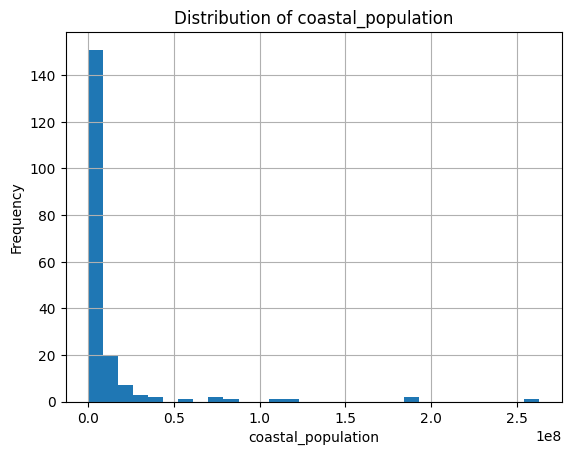

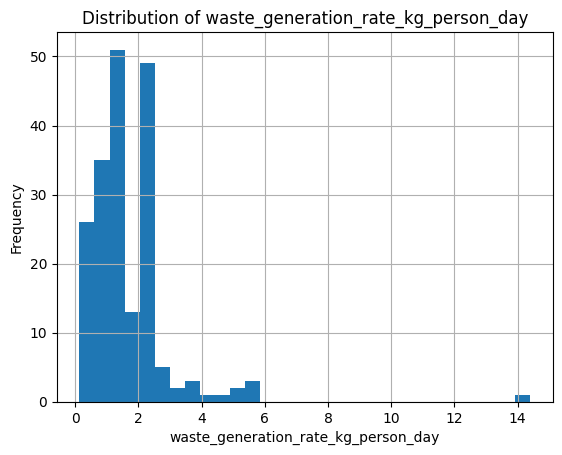

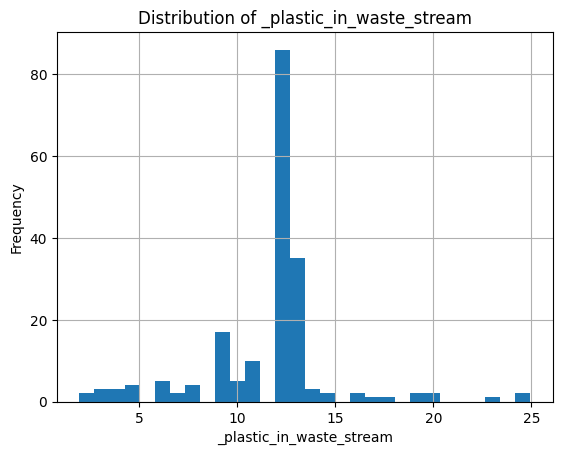

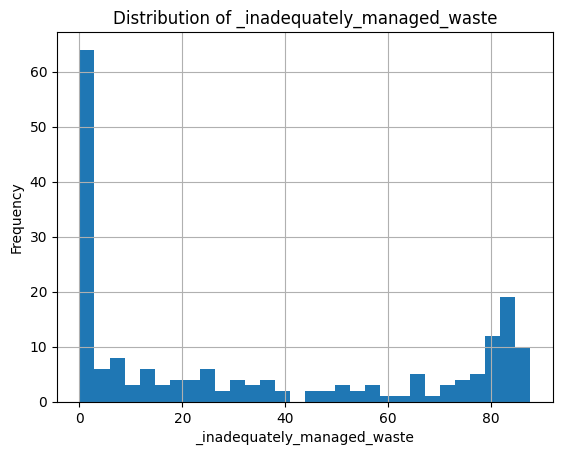

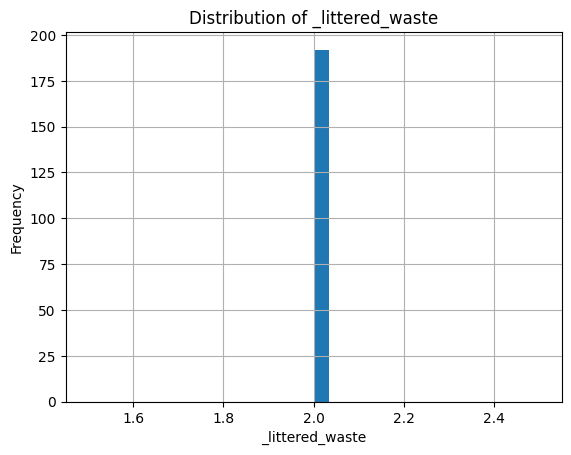

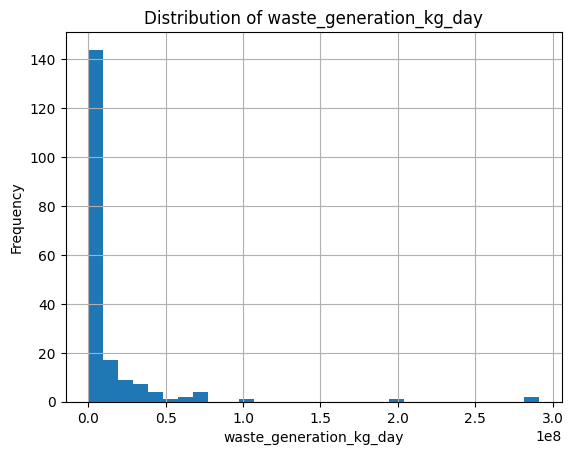

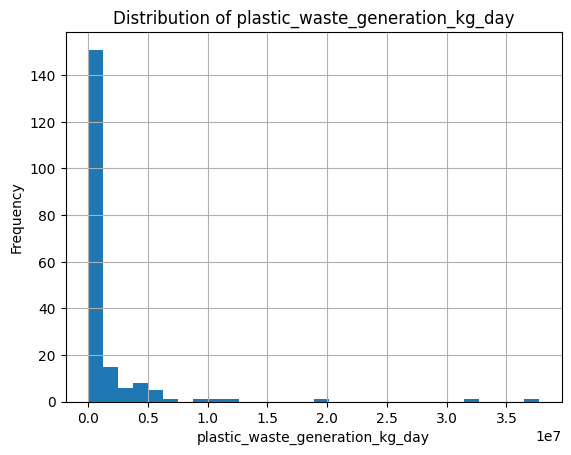

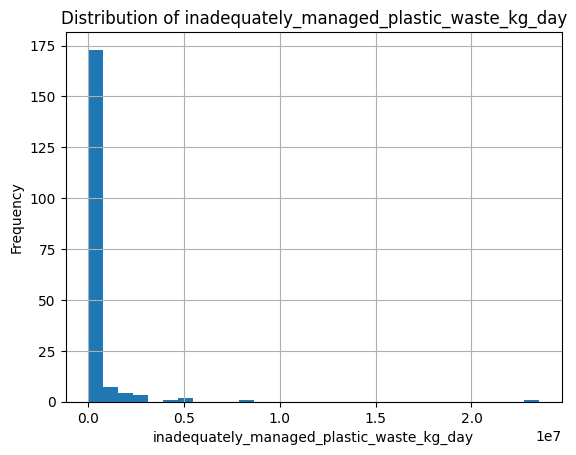

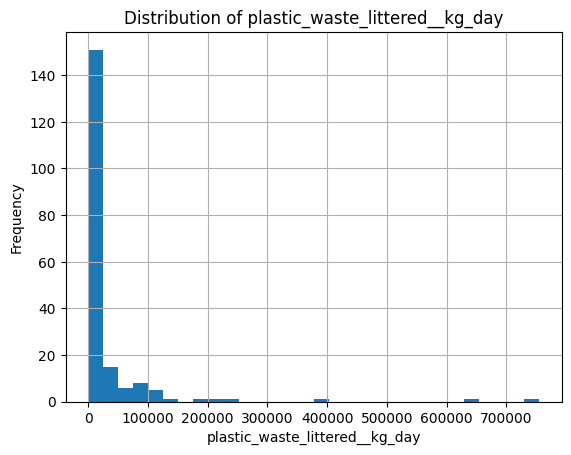

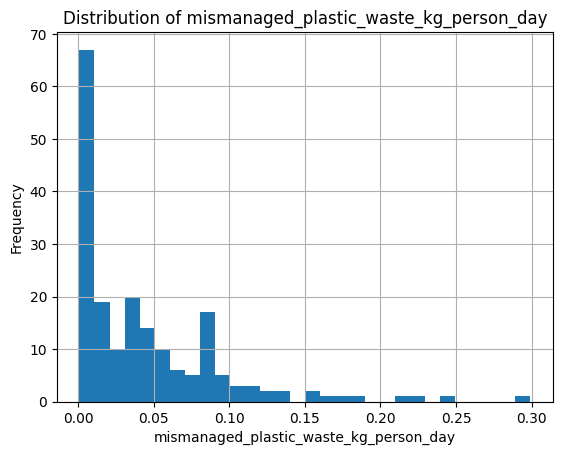

<Figure size 640x480 with 0 Axes>

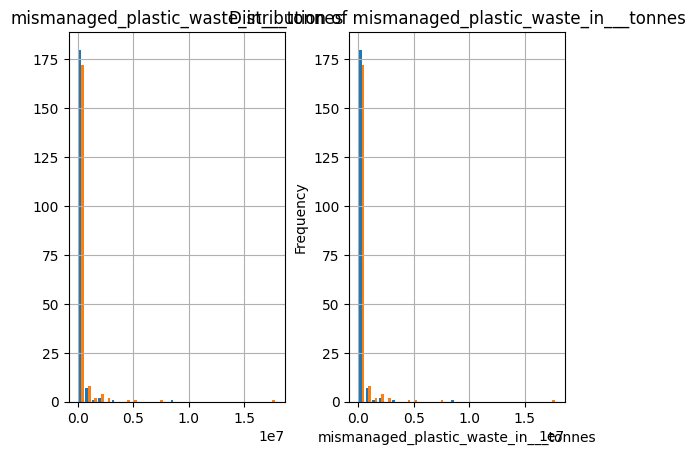

<Figure size 640x480 with 0 Axes>

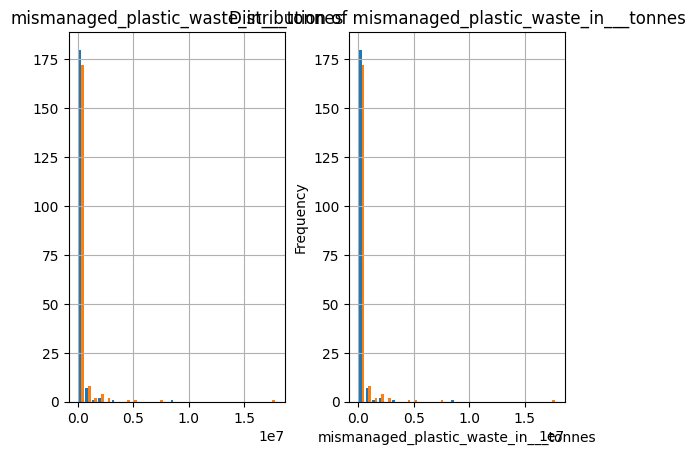

In [ ]:

num_cols = df1.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    plt.figure()
    df1[col].hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [45]:
skew_cols = [
    'coastal_population',
    'waste_generation_kg_day',
    'plastic_waste_generation_kg_day',
    'inadequately_managed_plastic_waste_kg_day',
    'plastic_waste_littered__kg_day',
    'mismanaged_plastic_waste_in___tonnes',
    'mismanaged_plastic_waste_in___tonnes'
]

for col in skew_cols:
    if col in df1.columns:
        df1[col] = np.log1p(df1[col])

In [48]:
num_cols = df1.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df1[col] = df1[col].clip(lower_bound, upper_bound)

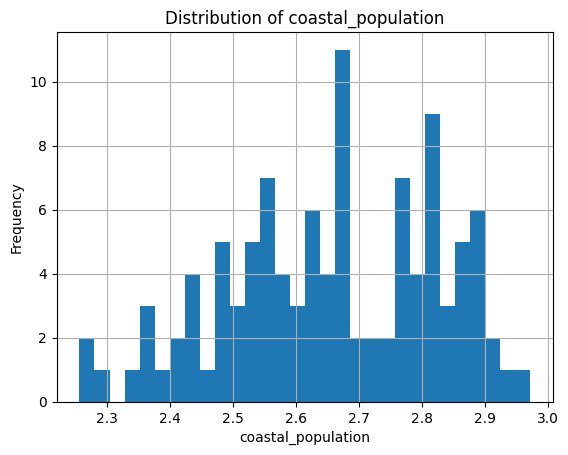

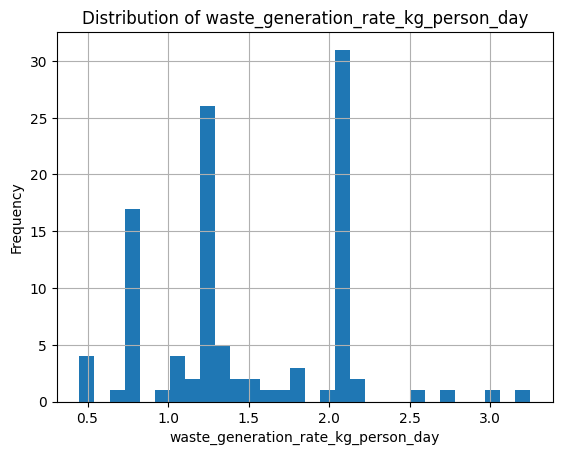

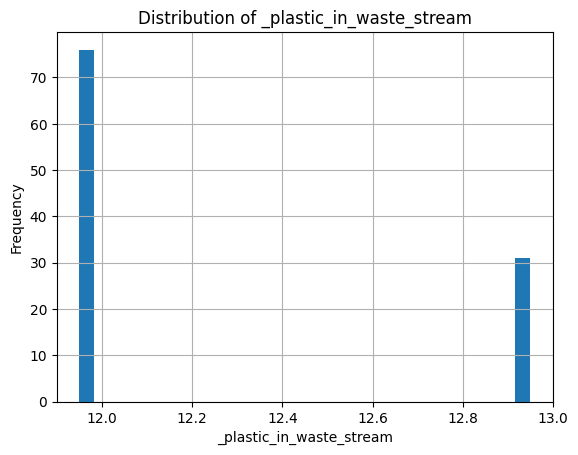

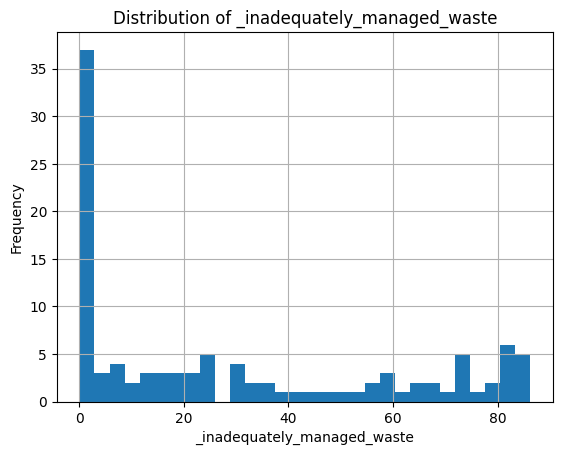

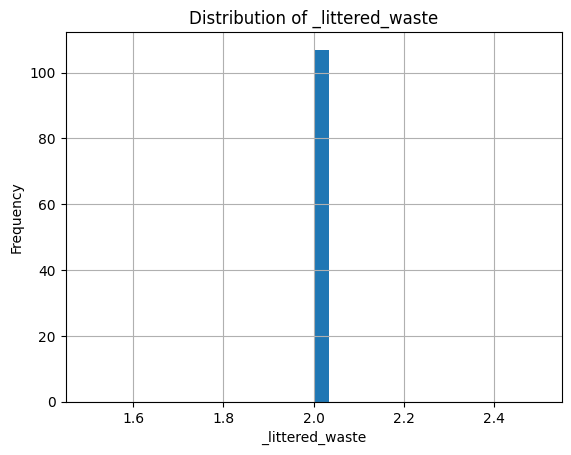

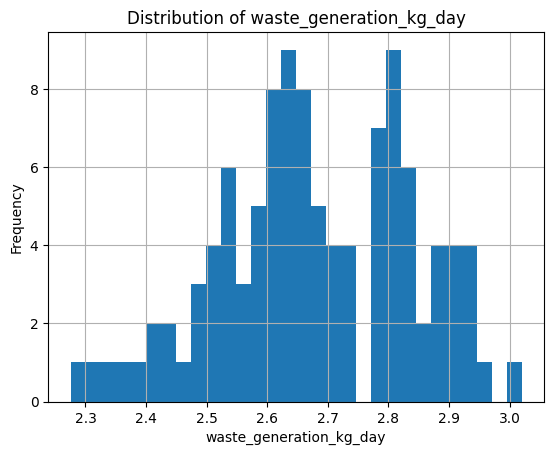

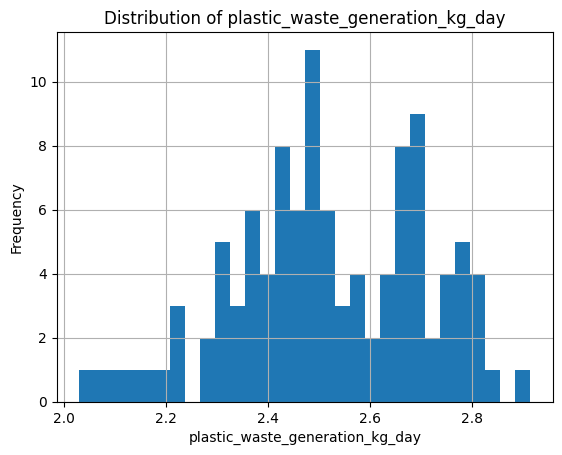

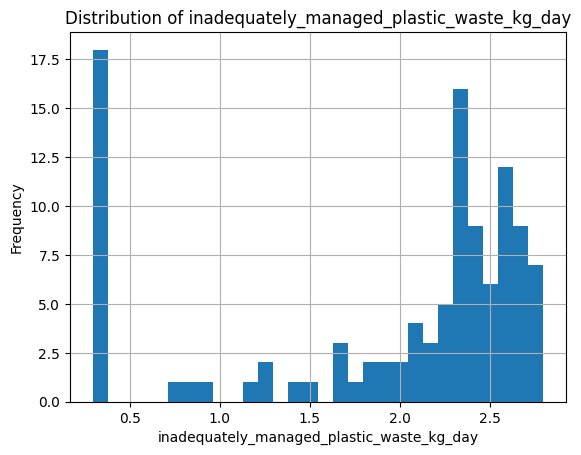

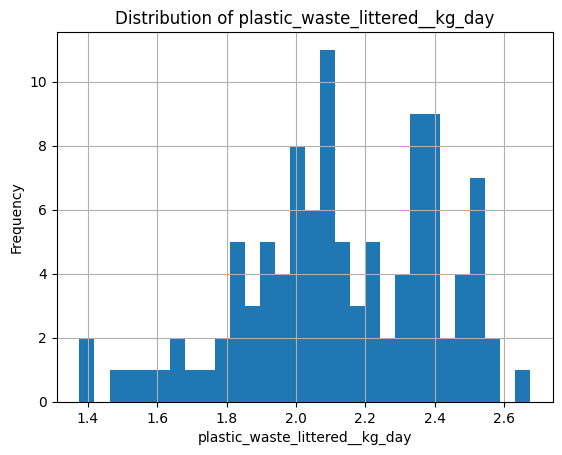

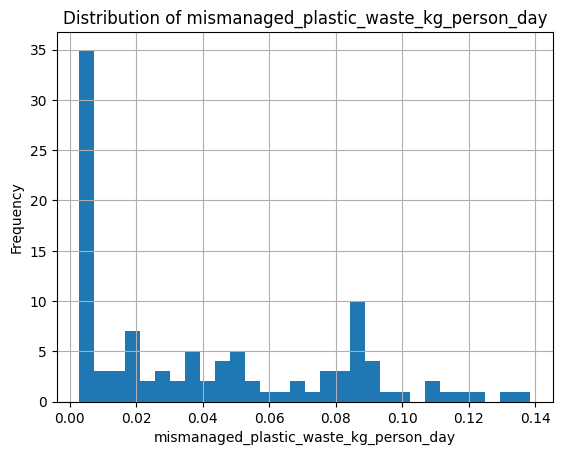

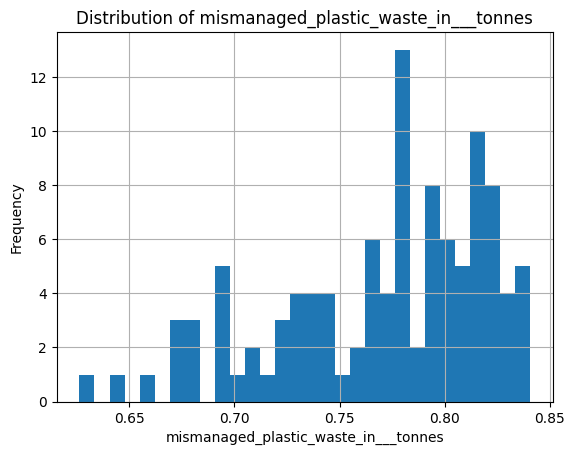

In [49]:
num_cols = df1.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    plt.figure()
    df1[col].hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Insights 

In [58]:
fig1 = px.scatter(
    df1,
    x="economic_status",
    y="_inadequately_managed_waste",
    size="plastic_waste_generation_kg_day",
    color="economic_status",
    hover_name="country",
    title="Economic Status vs Waste Mismanagement Efficiency",
    template="plotly_white"
)

fig1.show()

LMI — Lower Middle Income
UMI — Upper Middle Income
HIC — High Income Countries
Exploratory data analysis reveals a direct correlation between a country's economic status and its waste management efficiency.



In [60]:
top20 = df1.nlargest(20, 'mismanaged_plastic_waste_kg_person_day')
fig2 = px.bar(
    top20,
    x="country",
    y="mismanaged_plastic_waste_kg_person_day",
    color="mismanaged_plastic_waste_kg_person_day",
    color_continuous_scale="Reds",
    title="Top 20 Countries: Mismanaged Plastic Waste per Capita",
    template="plotly_white"
)

fig2.update_layout(xaxis_tickangle=-45)
fig2.show()

In [69]:
fig3 = px.scatter(
    df1,
    x="coastal_population",
    y="mismanaged_plastic_waste_in___tonnes",
     color="economic_status", 
     hover_name="country",
    title="Coastal Population vs Plastic Pollution"
 )

fig3.show()

there is a direct relation between population and waste in palstic

In [77]:
total_littered = df1['plastic_waste_littered__kg_day'].sum()
total_inadequate = df1['inadequately_managed_plastic_waste_kg_day'].sum()

fig5 = go.Figure(data=[go.Pie(
    labels=[
        "Littered Waste (Behavior)",
        "Inadequately Managed (System)"
    ],
    values=[total_littered, total_inadequate],
    hole=0.4
)])

fig5.update_layout(
    title="Behavior vs Infrastructure Failure in Waste Management",
    template="plotly_white"
)

fig5.show()

In [78]:
df1.to_csv("cleaned_data.csv", index=False)

# work on second data to modefiy AirQuality and WaterPollution

In [80]:
df2= pd.read_csv(r"C:\Users\USERR\Desktop\depi project\data\Cities1.csv")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3937 entries, 0 to 3936
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            3937 non-null   object 
 1   Region          3513 non-null   object 
 2   Country         3937 non-null   object 
 3   AirQuality      3937 non-null   float64
 4   WaterPollution  3937 non-null   float64
dtypes: float64(2), object(3)
memory usage: 153.9+ KB


In [81]:
df2.describe()

,AirQuality,WaterPollution
count,3937.000000,3937.000000
mean,62.444101,44.630317
std,30.927884,25.679613
min,0.000000,0.000000
25%,39.285714,25.000000
50%,70.000000,50.000000
75%,87.500000,57.777778
max,100.000000,100.000000


In [82]:
df2.describe(include='object')

,City,Region,Country
count,3937,3513,3937
unique,3771,1146,176
top,Cambridge,England,United States of America
freq,4,142,842


In [83]:
df2['Country'] = df2['Country'].str.strip().str.lower()
df2['City'] = df2['City'].str.strip()

In [84]:
df2['Region'].isna().sum()

np.int64(424)

In [85]:
df2 = df2.dropna(subset=['Region'])

In [86]:
df2 = df2.drop_duplicates(subset=['City', 'Country'])

In [87]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3446 entries, 0 to 3936
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            3446 non-null   object 
 1   Region          3446 non-null   object 
 2   Country         3446 non-null   object 
 3   AirQuality      3446 non-null   float64
 4   WaterPollution  3446 non-null   float64
dtypes: float64(2), object(3)
memory usage: 161.5+ KB


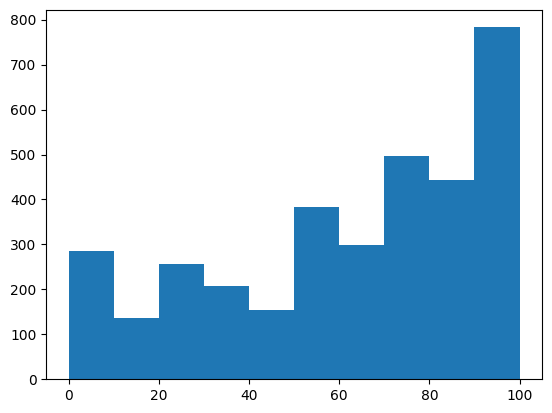

In [94]:
plt.hist(df2['AirQuality'])
plt.show()

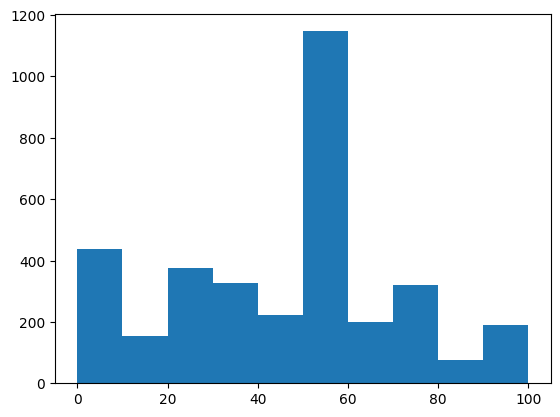

In [95]:
plt.hist(df2['WaterPollution'])
plt.show()

In [102]:
country_avg = df2.groupby('Country')[['AirQuality', 'WaterPollution']].mean().reset_index()

fig = px.choropleth(country_avg,
                    locations='Country',
                    locationmode='country names',
                    color='WaterPollution',
                    hover_name='Country',
                    color_continuous_scale='Reds',
                    title="Global Water Pollution Map")

fig.show()

C:\Users\USERR\AppData\Local\Temp\ipykernel_27920\1663164776.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(country_avg,


In [103]:
fig = px.choropleth(country_avg,
                    locations='Country',
                    locationmode='country names',
                    color='AirQuality',
                    hover_name='Country',
                    color_continuous_scale='Greens',
                    title="Global Air Quality Map")

fig.show()

C:\Users\USERR\AppData\Local\Temp\ipykernel_27920\269649991.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(country_avg,


In [107]:
df2.to_csv("cleaned_data2.csv", index=False)

# third data  wast management


In [2]:
df3 = pd.read_csv(r'C:\Users\USERR\Desktop\depi project\data\municipal-waste-management-method.csv')

In [3]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Entity                239 non-null    object 
 1   Code                  236 non-null    object 
 2   Year                  239 non-null    int64  
 3   Open dumps            239 non-null    float64
 4   Open burning          239 non-null    float64
 5   Controlled landfills  239 non-null    float64
 6   Sanitary landfills    239 non-null    float64
 7   Incinerated           239 non-null    float64
 8   Composted             239 non-null    float64
 9   Recycled              239 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 18.8+ KB


In [4]:
df3.head(10)

,Entity,Code,Year,Open dumps,Open burning,Controlled landfills,Sanitary landfills,Incinerated,Composted,Recycled
0,Afghanistan,AFG,2020,57.664207,36.685463,0.000000,0.000000,0.000000,4.214322,1.436008
1,Albania,ALB,2020,55.454403,21.115930,0.000000,0.000000,8.270926,3.638272,11.520468
2,Algeria,DZA,2020,2.000000,2.000000,5.840000,81.880000,0.000000,0.920000,7.360000
3,American Samoa,ASM,2020,16.971193,2.755225,33.942387,14.215969,21.348042,2.402240,8.364945
4,Andorra,AND,2020,11.975000,11.975000,23.950000,0.000000,52.100000,0.000000,0.000000
5,Angola,AGO,2020,54.050480,44.416702,0.000000,0.000000,0.000000,0.000000,1.532818
6,Anguilla,AIA,2020,23.705072,4.598170,47.410145,19.106901,0.125974,0.393740,4.659999
7,Antigua and Barbuda,ATG,2020,0.653191,0.653191,98.614730,0.000000,0.000000,0.078888,0.000000
8,Argentina,ARG,2020,22.842161,2.522500,13.046990,56.193752,0.000000,0.000000,5.394600
9,Armenia,ARM,2020,85.000000,5.000000,10.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
df3.drop(columns=['Code'])

,Entity,Year,Open dumps,Open burning,Controlled landfills,Sanitary landfills,Incinerated,Composted,Recycled
0,Afghanistan,2020,57.664207,36.685463,0.000000,0.000000,0.000000,4.214322,1.436008
1,Albania,2020,55.454403,21.115930,0.000000,0.000000,8.270926,3.638272,11.520468
2,Algeria,2020,2.000000,2.000000,5.840000,81.880000,0.000000,0.920000,7.360000
3,American Samoa,2020,16.971193,2.755225,33.942387,14.215969,21.348042,2.402240,8.364945
4,Andorra,2020,11.975000,11.975000,23.950000,0.000000,52.100000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
234,Venezuela,2020,91.362144,8.637856,0.000000,0.000000,0.000000,0.000000,0.000000
235,Vietnam,2020,36.320000,36.320000,0.000000,0.000000,0.000000,10.800000,16.560000
236,Yemen,2020,27.750000,22.750000,47.900000,0.000000,0.000000,0.000000,1.600000
237,Zambia,2020,53.506910,45.165977,0.000000,0.000000,0.000000,0.000000,1.327115


In [7]:
df3.describe()

,Year,Open dumps,Open burning,Controlled landfills,Sanitary landfills,Incinerated,Composted,Recycled
count,239.0,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000
mean,2020.0,33.626682,14.171084,20.623038,12.944726,6.177639,2.799748,9.653456
std,0.0,26.634278,16.146320,24.852418,19.696391,15.343280,5.447314,12.962782
min,2020.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.0,15.593462,0.972658,0.000000,0.000000,0.000000,0.000000,0.546246
50%,2020.0,24.184967,5.847500,7.575389,2.000000,0.000000,0.081900,4.659999
75%,2020.0,58.190425,24.767250,43.068833,18.924436,0.353360,2.637000,16.395000
max,2020.0,100.000000,50.000000,99.050000,89.590000,85.000000,31.240000,66.945480
